## Import CUDA

In [1]:
from numba import cuda

## Load the image

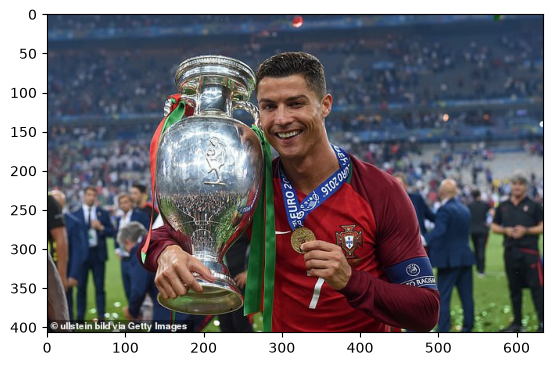

In [2]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')

plt.imshow(image)

h, w, d = image.shape

## RGB to HSV (scatter, AoS to SoA)

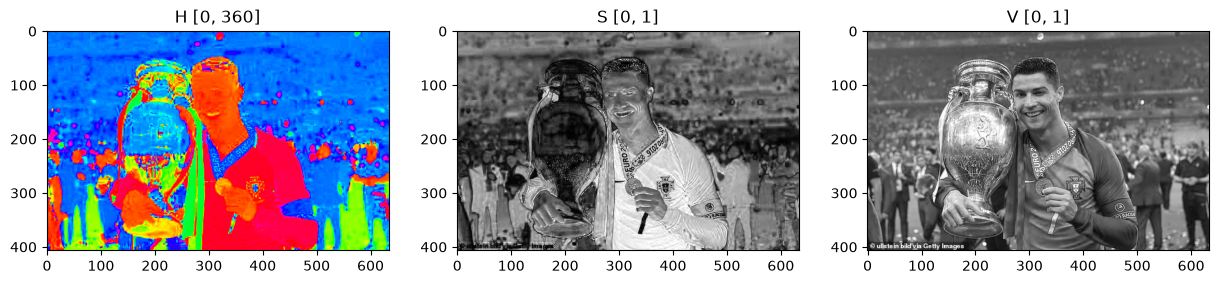

In [ ]:
@cuda.jit
def RGB2HSV(src, H, S, V):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    
    r = src[tidy, tidx, 0] / 255
    g = src[tidy, tidx, 1] / 255
    b = src[tidy, tidx, 2] / 255
    mx = max(r, g, b)
    mn = min(r, g, b)
    delta = mx - mn

    # H conversion
    if delta == 0:
        hue = 0.0
    elif mx == r:
        hue = 60 * (((g - b) / delta) % 6)
    elif mx == g:
        hue = 60 * ((b - r) / delta + 2)
    else:
        hue = 60 * ((r - g) / delta + 4)

    # S conversion
    if mx == 0:
        sat = 0.0
    else:
        sat = delta / mx

    # scatter: one pixel (R, G, B) goes to 3 different arrays
    H[tidy, tidx] = hue
    S[tidy, tidx] = sat
    V[tidy, tidx] = mx

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
devSrc = cuda.to_device(image)
devH = cuda.device_array((h, w), np.float32)
devS = cuda.device_array((h, w), np.float32)
devV = cuda.device_array((h, w), np.float32)
RGB2HSV[gridSize, blockSize](devSrc, devH, devS, devV)
H = devH.copy_to_host()
S = devS.copy_to_host()
V = devV.copy_to_host()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(H, cmap='hsv', vmin=0, vmax=360)
plt.title("H [0, 360]")
plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray', vmin=0, vmax=1)
plt.title("S [0, 1]")
plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray', vmin=0, vmax=1)
plt.title("V [0, 1]")
plt.show()

## HSV to RGB

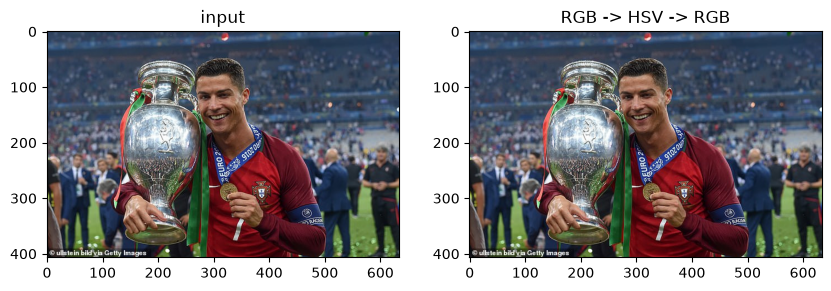

In [6]:
@cuda.jit
def HSV2RGB(src,dst, H, S, V):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return

    # Preparation
    d = H[tidy,tidx] / 60
    hi = int(d) % 6
    f = d - hi
    l = V[tidy,tidx] * (1 - S[tidy,tidx])
    m = V[tidy,tidx] * (1 - f * S[tidy,tidx])
    n = V[tidy,tidx] * (1 - (1-f) * S[tidy,tidx])

    # Conversion 
    if 0 <= H[tidy,tidx] < 60:
        R = V[tidy,tidx]
        G = n
        B = l
    elif 60 <= H[tidy,tidx] < 120:
        R = m
        G = V[tidy,tidx]
        B = l
    elif 120 <= H[tidy,tidx] < 180:
        R = l
        G = V[tidy,tidx]
        B = n
    elif 180 <= H[tidy,tidx] < 240:
        R = l
        G = m
        B = V[tidy,tidx]
    elif 240 <= H[tidy,tidx] < 300:
        R = n
        G = l
        B = V[tidy,tidx]
    else:
        R = V[tidy,tidx]
        G = l
        B = m
    R = R * 255
    G = G * 255
    B = B * 255

    dst[tidy,tidx,0] = R
    dst[tidy,tidx,1] = G
    dst[tidy,tidx,2] = B

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
devDst = cuda.device_array((h, w, 3), np.uint8)
HSV2RGB[gridSize, blockSize](devSrc, devDst, devH, devS, devV)
result = devDst.copy_to_host()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("input")
plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("RGB -> HSV -> RGB")
plt.show()
